# Deep Hedging

**Reference paper:**
- Deep Hedging - Buehler and al. 2018 
    https://arxiv.org/abs/1802.03042
- Equal risk pricing of financial derivative with deep hedging - Carbonneau, Godin. 2020
- Deep Learning - Goodfellow et al. 2016

**Reference code:**
- Equal risk pricing with deep hedging - Carbonneau
    https://github.com/alexandrecarbonneau/Equal-risk-pricing-with-deep-hedging/blob/master/Example%20of%20ERP%20with%20deep%20hedging.ipynb
- Deep Hedging
    https://nbviewer.org/urls/people.math.ethz.ch/~jteichma/lecture_ml_web/lecture_3.ipynb
- Option hedging with a Long-Short-Term-Memory Recurrent Neural Network mgroncki
    https://github.com/mgroncki/DataScienceNotebooks/blob/master/DeepHedging/DeepHedging_Part1.ipynb


# Objective

Implement a simple deep hedging framework to hedge an European call option on the underlying Black-Scholes model.

# 0. Packages

In [3]:
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Hedging Problem

You are short a European call option. At each rebalancing step $t$, you hold $\delta_t$ shares of the underlying. The P&L of the hedged portfolio is:

$$\text{P\&L} = -\text{Payoff}(S_T) + \sum_{t=0}^{T-1} \delta_t (S_{t+1} - S_t) - \text{Transaction Cost}$$

The goal is to learn $\delta_t = f_\theta(\text{state}_t)$ that minimizes a risk measure (e.g., CVaR) of the terminal P&L.

# 2. Black-Scholes Model

Recall in the Black-Scholes framework, the asset price $S_t$ a Geometric Brownian Motion (GBM):

$$
dS_t = r \, S_t \, dt + \sigma \, S_t \, dW_t
$$
where $r$ is the risk free rate, $\sigma$ is the volatility (constant), and $W_t$ is a standard Brownian motion with respect to the risk neutral measure $Q$.


Given $\mathcal{F}_s$ , $s \leq t$, we obtain, using Ito's,
$$
S_t = S_s \, e^{(r - \frac{\sigma^2}{2}) \, (t-s) \ + \ \sigma  \, (W_t - W_s)}
$$
Equivalent to 
$$
S_t = S_s \, e^{(r - \frac{\sigma^2}{2}) \, (t-s) \ + \ \sigma \, \sqrt{t-s} \, Z_t}
$$
where $Z_t \sim \mathcal{N}(0,1)$

### (a) Simulate BS paths

In [4]:
def BS_paths(S0, r, sigma, T, N_steps, M_paths, seed = 123):
    """
    This function simulate (M_paths) Black-Scholes paths from 0 to maturity T,
    with number of discretization (N_steps)
    return shape is (N_steps + 1, M_paths + 1), 
    e.g. first column is each column is a simulation
    """
    np.random.seed(seed)
    dt = T / N_steps
    Z = np.random.randn(M_paths, N_steps)
    log_return = (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_S = np.log(S0) + np.cumsum(log_return, axis=1)
    S = np.exp(log_S)
    S = np.column_stack([np.full(M_paths, S0), S])
    t = np.linspace(0, T, N_steps + 1)

    return S.astype(np.float32), t


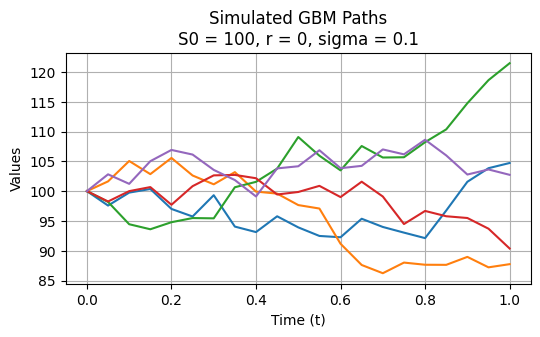

In [5]:
# plot GBM

r = 0
sigma = 0.1
S0 = 100
S, t = BS_paths(S0 = S0, r = r, sigma = sigma, T = 1, N_steps = 20, M_paths = 5)

plt.figure(figsize=(6, 3)) 
plt.plot(t, np.transpose(S), label='S_t')

plt.title(f'Simulated GBM Paths\nS0 = {S0}, r = {r}, sigma = {sigma}')    
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.grid()
plt.show()

### (b) Black-Scholes Hedging Framework

The Black-Scholes European call price is:
$$
C(S, t) = S\, \Phi(d_1) - K e^{-r(T-t)} \Phi(d_2)
$$

where $\Phi(\cdot)$ is the standard normal CDF and:
$$
d_1 = \frac{\ln(S/K) + \left(r + \frac{1}{2}\sigma^2\right)(T-t)}{\sigma\sqrt{T-t}}, \qquad d_2 = d_1 - \sigma\sqrt{T-t}
$$

Taking the first partial derivative with respect to the asset price $S$ (called *delta*)
$$
\delta = \frac{\partial C}{\partial S} = \Phi(d_1)
$$
with $\delta \in [0,1]$ (by cdf of normal)


In the Black-Scholes delta hedging framework, the rebalancing rule is:

At each time step $t$, hold $\delta_t$ shares of the underlying $S_t$:

$$\delta_t = \Phi(d_1(S_t, t))$$

The hedge P&L accumulated over one step is:

$$\text{PnL}_t = \delta_{t-1} \cdot (S_t - S_{t-1})$$

and the total hedged portfolio value at maturity is:

$$\text{PnL}_{\text{total}} = \text{Call Premium} + \sum_{t=1}^{T} \text{PnL}_t - \text{Payoff}$$

In [6]:
# option pricing with Black Scholes
class BlackScholes:
    def __init__(self, S, K, r, sigma, T):
        self.S = S   # current asset price
        self.K = K   # strike
        self.r = r   # risk free rate
        self.sigma = sigma   #volatility
        self.T = T   # time to maturity

    def call_price(self):  
        d1 = (np.log(self.S/self.K) + (self.r + 0.5*(self.sigma**2))*self.T)/(self.sigma * np.sqrt(self.T))
        d2 = d1 - sigma*np.sqrt(self.T)
        return self.S*norm.cdf(d1) - self.K*np.exp(-self.r*self.T)*norm.cdf(d2)
    def put_price(self):  # by put call parity
        return self.call_price() - self.S + self.K*np.exp(-self.r * self.T)
    
    def call_delta(self):  # first derivative with respect to price S 
        d1 = (np.log(self.S/self.K) + (self.r + 0.5*(self.sigma**2))*self.T)/(self.sigma * np.sqrt(self.T))
        return norm.cdf(d1)
    def put_delta(self):   # by derivative of put-call parity with respect to S
        return self.call_delta() - 1

In [19]:
# Delta hedging

def delta_hedging(S, K, r, sigma, T):
    # parameters
    ttm = np.linspace(T, 0,S.shape[1])
    S0 = S[0,0]
    dt = T/(S.shape[1] - 1)

    # call price value (initial value of the hedging portfolio)
    call_price = BlackScholes(S0, K, r, sigma, T).call_price()
    call_price_maturity = np.full(S.shape[0], call_price) * np.exp(r * T)

    # payoff (at maturity)
    payoff = np.maximum(S[:,-1] - K, 0)

    # delta (not at maturity)
    S_grid = S[:,:-1]
    T_grid = ttm[:-1]
    
    d1 = (np.log(S_grid/K) + (r + 0.5*(sigma**2))*T_grid)/(sigma * np.sqrt(T_grid))
    deltas = norm.cdf(d1)

    # pnl at each step t = 1 to T-1 

    compound = np.exp(r * (T - ttm[1:]))      # compounding each gain to maturity
    dS = S[:, 1:] - S[:, :-1] * np.exp(r * dt)         # discounted stock move
    hedging_pnl = np.sum(deltas * dS * compound, axis=1)

    # total pnl
    pnl = call_price_maturity + hedging_pnl - payoff

    return pnl

In [ ]:
# test results
S, t = BS_paths(S0 = S0, r = 0.1, sigma = sigma, T = 1, N_steps = 1000, M_paths = 1000)
delta_hedging_pnl = delta_hedging(S=S, K=100, r=0.1, sigma=0.1, T=1)
print(np.mean(delta_hedging_pnl), np.std(delta_hedging_pnl))

-0.002869502764772589 0.588503866886128
